In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest,
    confint_proportions_2indep
)

In [2]:
baseline_conversion = 0.514956577677

print(f"Baseline conversion: {baseline_conversion:.2%}")

Baseline conversion: 51.50%


In [3]:
relative_lifts = [0.05, 0.10, 0.15]

scenarios = []

for lift in relative_lifts:

    treatment_rate = baseline_conversion * (1 + lift)

    scenarios.append({
        "relative_lift": lift,
        "baseline_rate": baseline_conversion,
        "treatment_rate": treatment_rate,
        "absolute_lift": treatment_rate - baseline_conversion
    })

scenario_df = pd.DataFrame(scenarios)

scenario_df

,relative_lift,baseline_rate,treatment_rate,absolute_lift
0,0.05,0.514957,0.540704,0.025748
1,0.10,0.514957,0.566452,0.051496
2,0.15,0.514957,0.592200,0.077243


calculate the required sample size for each scenario

In [4]:
power_analysis = NormalIndPower()

alpha = 0.05
power = 0.80

sample_size_results = []

for _, row in scenario_df.iterrows():

    effect_size = proportion_effectsize(
        row["treatment_rate"],
        row["baseline_rate"]
    )

    sample_size = power_analysis.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative="larger"
    )

    sample_size_results.append(
        int(np.ceil(sample_size))
    )

scenario_df["sample_size_per_variant"] = sample_size_results

scenario_df["total_sample_size"] = (
    scenario_df["sample_size_per_variant"] * 2
)

scenario_df

,relative_lift,baseline_rate,treatment_rate,absolute_lift,sample_size_per_variant,total_sample_size
0,0.05,0.514957,0.540704,0.025748,4648,9296
1,0.10,0.514957,0.566452,0.051496,1157,2314
2,0.15,0.514957,0.592200,0.077243,512,1024


estimated experiment durations for each scenario

In [5]:
average_daily_eligible_sessions = 33.79347826086

scenario_df["estimated_days"] = np.ceil(
    scenario_df["total_sample_size"]
    /
    average_daily_eligible_sessions
).astype(int)

scenario_df

,relative_lift,baseline_rate,treatment_rate,absolute_lift,sample_size_per_variant,total_sample_size,estimated_days
0,0.05,0.514957,0.540704,0.025748,4648,9296,276
1,0.10,0.514957,0.566452,0.051496,1157,2314,69
2,0.15,0.514957,0.592200,0.077243,512,1024,31


code cell for the required sample-size chart

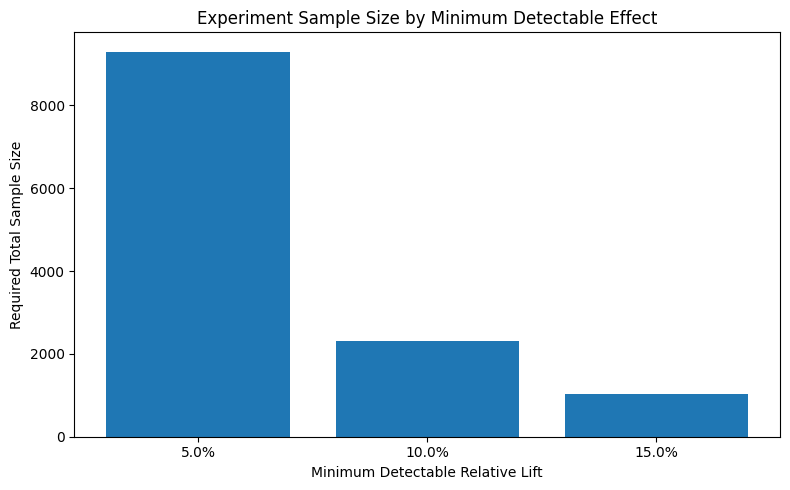

In [6]:
plot_df = scenario_df.copy()

plot_df["relative_lift_pct"] = (
    plot_df["relative_lift"] * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["relative_lift_pct"].astype(str) + "%",
    plot_df["total_sample_size"]
)

plt.xlabel("Minimum Detectable Relative Lift")
plt.ylabel("Required Total Sample Size")
plt.title("Experiment Sample Size by Minimum Detectable Effect")

plt.tight_layout()
plt.show()

simulated A/B test


In [7]:
selected_lift = 0.10

treatment_conversion = (
    baseline_conversion
    *
    (1 + selected_lift)
)

required_n = int(
    scenario_df.loc[
        scenario_df["relative_lift"] == selected_lift,
        "sample_size_per_variant"
    ].iloc[0]
)

print("Control conversion:", baseline_conversion)
print("Simulated treatment conversion:", treatment_conversion)
print("Users per variant:", required_n)

Control conversion: 0.514956577677
Simulated treatment conversion: 0.5664522354447
Users per variant: 1157


required reproducible simulation step using seed 42

In [8]:
rng = np.random.default_rng(42)

control_conversions = rng.binomial(
    n=required_n,
    p=baseline_conversion
)

treatment_conversions = rng.binomial(
    n=required_n,
    p=treatment_conversion
)

print("Control conversions:", control_conversions)
print("Treatment conversions:", treatment_conversions)

Control conversions: 610
Treatment conversions: 684


calculate the observed control/treatment conversion and the absolute + relative lift,

In [9]:
observed_control_rate = (
    control_conversions / required_n
)

observed_treatment_rate = (
    treatment_conversions / required_n
)

absolute_lift = (
    observed_treatment_rate
    -
    observed_control_rate
)

relative_lift = (
    absolute_lift
    /
    observed_control_rate
)

print(
    f"Observed control rate: "
    f"{observed_control_rate:.2%}"
)

print(
    f"Observed treatment rate: "
    f"{observed_treatment_rate:.2%}"
)

print(
    f"Absolute lift: "
    f"{absolute_lift:.2%}"
)

print(
    f"Relative lift: "
    f"{relative_lift:.2%}"
)

Observed control rate: 52.72%
Observed treatment rate: 59.12%
Absolute lift: 6.40%
Relative lift: 12.13%


two-proportion z-test

Because 0.0010 < 0.05, the simulated treatment result is statistically significant at the one-sided 5% level.

In [10]:
conversion_counts = np.array([
    treatment_conversions,
    control_conversions
])

sample_sizes = np.array([
    required_n,
    required_n
])

z_statistic, p_value = proportions_ztest(
    count=conversion_counts,
    nobs=sample_sizes,
    alternative="larger"
)

print(f"Z-statistic: {z_statistic:.3f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 3.098
P-value: 0.0010


95% confidence interval

Because the entire interval is above 0%, the simulated treatment effect is consistent with a positive improvement, not just a statistically significant p-value

In [11]:
ci_low, ci_high = confint_proportions_2indep(
    count1=treatment_conversions,
    nobs1=required_n,

    count2=control_conversions,
    nobs2=required_n,

    method="wald"
)

print(
    f"95% CI for treatment-control difference: "
    f"[{ci_low:.2%}, {ci_high:.2%}]"
)

95% CI for treatment-control difference: [2.36%, 10.43%]


SIMULATED/MODELED

In [12]:
average_order_value = 69.86609240407

incremental_conversions = (
    treatment_conversions
    -
    (
        required_n
        *
        observed_control_rate
    )
)

modeled_incremental_revenue = (
    incremental_conversions
    *
    average_order_value
)

print(
    f"Modeled incremental conversions: "
    f"{incremental_conversions:.0f}"
)

print(
    f"Modeled incremental revenue: "
    f"${modeled_incremental_revenue:,.2f}"
)

Modeled incremental conversions: 74
Modeled incremental revenue: $5,170.09


DECISION/RESULT

## Experiment Decision Framework

The simulated treatment produced:

- Control conversion rate: 52.72%
- Treatment conversion rate: 59.12%
- Absolute lift: 6.40 percentage points
- Relative lift: 12.13%
- One-sided p-value: 0.0010
- 95% confidence interval for the treatment-control difference: 2.36% to 10.43%
- Modeled incremental conversions: 74
- Modeled incremental revenue: $5,170.09

### Decision

The simulated treatment would meet the statistical significance threshold because the p-value is below 0.05 and the confidence interval is entirely above zero.

However, this result is based on simulated treatment outcomes and does not represent observed causal business impact.

A real experiment should only be rolled out after confirming:
- statistical significance,
- acceptable guardrail performance,
- no sample-ratio mismatch,
- stable tracking quality,
- and sufficient runtime across normal business cycles.

## Guardrails, SRM, and Experiment Limitations

### Guardrail Metrics

The experiment should monitor:

- Average order value
- Revenue per checkout
- Purchase-event tracking quality
- Checkout abandonment rate

A treatment should not be rolled out if it improves the primary conversion metric while materially harming revenue quality or measurement reliability.

### Sample Ratio Mismatch

The experiment is designed for a 50/50 allocation between control and treatment.

During a real experiment, observed assignment counts should be checked for sample ratio mismatch before interpreting treatment effects.

Unexpected imbalance may indicate:
- experiment assignment issues,
- instrumentation problems,
- traffic filtering differences,
- or data loss.

### Limitations

The public GA4 dataset does not contain a real randomized experiment.

Historical GA4 behavior is used only to:
- establish the baseline conversion rate,
- estimate eligible traffic,
- design sample-size requirements,
- and model experiment feasibility.

The treatment outcomes in this notebook are simulated.

Therefore:
- the p-value is based on simulated outcomes,
- the confidence interval is based on simulated outcomes,
- and the modeled incremental revenue must not be interpreted as realized causal business impact.